In [44]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [45]:
# 1. Create LTM store + seed memories (done BEFORE running the graph)


store = InMemoryStore()

user_id = "u1"


# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.


# namespace below:
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Aneesh"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [46]:
# 2. System prompt template (your prompt)


SYSTEM_PROMPT_TEMPLATE = """

You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Aneesh...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}

"""

In [47]:
# 3. Build graph: START -> chat -> END (read-only LTM)

llm = ChatOpenAI(
    model="gpt-4o-mini"
)

In [48]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    # Retrive the user_id first from config
    user_id = config["configurable"]["user_id"]
    
    # Now retrive the user details from the store
    user_details = ("user", user_id, "details")
    
    # Now we fetch all the memories present in the store (not overcomplicating here by doing semantic search, just fetching all the memories for simplicity)
    items = store.search(user_details)
    
    
    # Now we join all the memories divided by a "-" ("memory1 - memory2 - memory3") to form a single string to be used in the system prompt
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty
        
        
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    
    
    # We're not just sending the current message but also the previous conversation history through system message (which has the context of the previously store memories)
    response = llm.invoke([system_msg] + state["messages"])
    
    return {"messages": [response]}
    
        
    

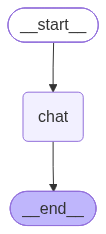

In [49]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [50]:
# 4. Run it (provide user_id in config)


config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)


Sure, Aneesh! Generative AI refers to a type of artificial intelligence that can create new content. This includes text, images, music, and more, based on the data it has been trained on. It works by learning patterns and structures from existing content and then generating new examples that resemble that input.

For example, if you train a generative AI model on a dataset of images of cats, it can create new images that look like cats but are not copied from the dataset. Similarly, in text generation, it can write new stories or essays by learning from a variety of written materials.

Would you like more specific examples related to a certain area of interest, perhaps in Python, or how it relates to your teaching content? Here are three follow-up questions for you:

1. Are you looking for specific applications of generative AI in your teaching?
2. Would you like to explore a Python library that can help you implement generative AI?
3. Are there particular types of content (like text o

### Chatbot Creating New Memories (without Duplications)

In [51]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [52]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [53]:

# ----------------------------
# 2) LLMs
#    - memory_llm: extracts candidate memories + tells if each is NEW (no duplicate_of needed)
# ----------------------------
memory_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [54]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [55]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [56]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [57]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [ ]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories (If decison.should_write is True then only we do)
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text}) # add unique keys with uuid everytime

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [60]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [61]:
config = {"configurable": {"user_id": "u1"}}

In [64]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Aneesh"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [65]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

The user's name is Nitish.
The user's name is Aneesh.


### Merged Workflow 

In [66]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [67]:
# ----------------------------
# 1) LTM store (START EMPTY)
# ----------------------------
store = InMemoryStore()

In [ ]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Aneesh...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [69]:
# ----------------------------
# 3) Memory extraction LLM
# ----------------------------
memory_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [70]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, false if duplicate")

In [71]:
class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [72]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)


In [73]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [74]:
# ----------------------------
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [75]:
# ----------------------------
# 5) Node 2: chat
# ----------------------------
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [76]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

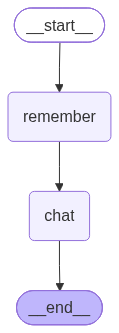

In [77]:
# ----------------------------
# 6) Graph
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [78]:
# ----------------------------
# 7) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

In [79]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Aneesh"}]}, config)
result['messages'][-1].content

"Hi Aneesh! It's great to meet you. How can I assist you today?"

In [80]:

for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Aneesh.


In [81]:
result = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on YouTube"}]}, config)
print(result['messages'][-1].content)

That's great to hear, Aneesh! Teaching AI on YouTube must be a rewarding experience. What kind of content do you focus on—tutorials, discussions on AI trends, or something else? If you have any specific challenges or projects you’re working on for your channel, feel free to share! 

Here are a few questions you might consider:
1. What topics in AI do you find resonate the most with your audience?
2. Are there any tools or software you often use to create your videos?
3. Have you thought about collaborations with other YouTubers or professionals in the AI field?


In [82]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Aneesh.
Aneesh teaches AI on YouTube.


In [83]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Sure, Aneesh! Generative AI, or GenAI, refers to a type of artificial intelligence that can create new content. This can include writing text, generating images, composing music, or even creating videos based on the input it receives.

In simple terms, think of it as a smart tool that learns from existing data (like books, art, or music) and uses that knowledge to produce original works. For instance, if you give it a prompt, it can generate a story or an article that fits your request.

It’s particularly exciting because it enables creativity and innovation across various fields, including education, art, and entertainment. 

If you’re ever looking for specific examples or applications of GenAI that could be interesting for your YouTube teachings, let me know!

Here are a few questions you might find useful:
1. Are there specific aspects of GenAI you’d like to explore more deeply for your audience?
2. Would you like suggestions on practical GenAI tools for teaching purposes?
3. Do you

In [84]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Aneesh.
Aneesh teaches AI on YouTube.
